# MMFDB · Photon-by-photon H2MM

> ⚠️ **Experimental.** ChiSurf's H2MM engine is validated against the reference
> implementation but is still being refined.

**H2MM** recovers hidden FRET states from every photon. We simulate two states
with known efficiencies, store them in MMFDB, and check the recovery. For a
deeper tour (model selection, engines, static vs dynamic) see
`chisurf/plugins/burst/burst_h2mm/examples/H2MM_02_MMFDB_GroundTruth.ipynb`.

In [1]:
%matplotlib inline
import logging, warnings
for _n in ("numexpr", "mmfdb"):
    logging.getLogger(_n).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message="nopython is set for njit")

import numpy as np
import matplotlib.pyplot as plt
from chisurf.plugins.burst.burst_analysis.api import BurstWorkflow

## Simulate, store, select, recover

In [2]:
wf = BurstWorkflow.demo()
sim = wf.simulate(fret=(0.25, 0.75), exchange_rate=2.0)
bursts = wf.select_bursts(sim.handle, setup=sim.setup, min_photons=20)
h2mm = bursts.h2mm(states=(1, 2, 3))
print(h2mm.summary())
print("\nGround truth was:", np.round(sim.truth.fret, 2).tolist())

Best model: 2 state(s) (engine=em, criterion=bic)
  state 0: FRET E = 0.25, population = 49%
  state 1: FRET E = 0.75, population = 51%

Ground truth was: [0.25, 0.75]


## The H2MM dashboard

Recovered states, model selection (BIC/ICL vs number of states), transition
rates, and dwell-time distributions.

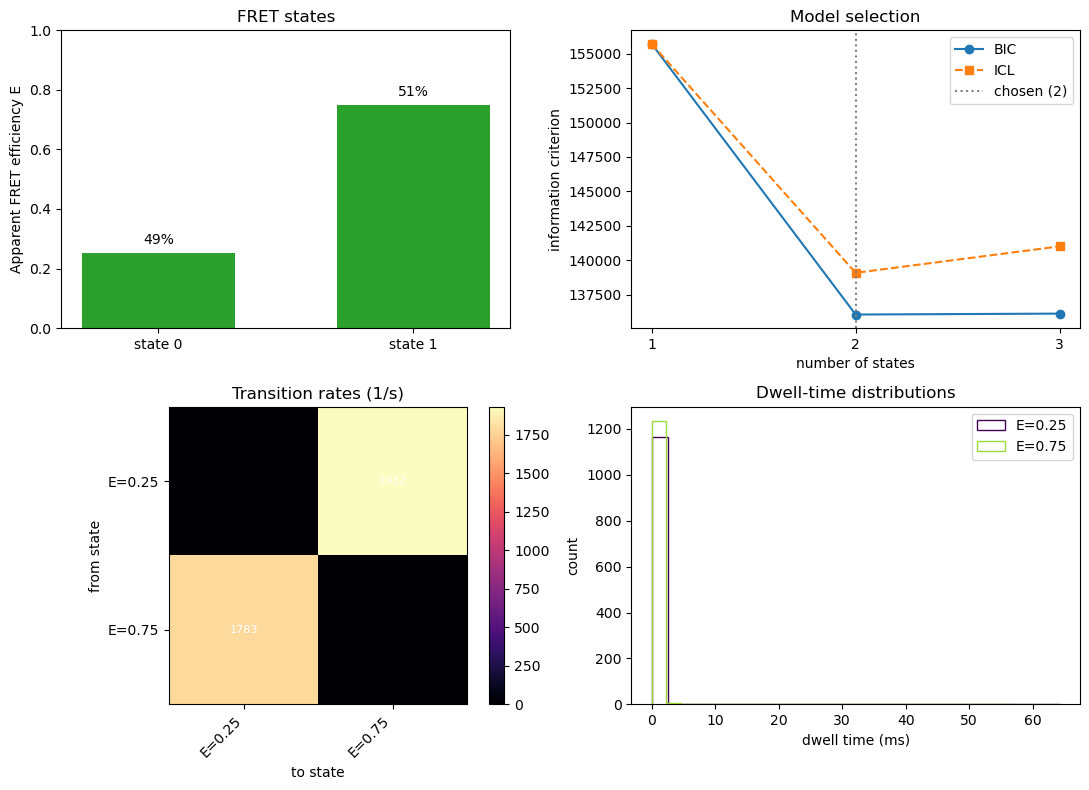

In [3]:
h2mm.plot()
plt.show()

In [4]:
wf.close()
print("Finished.")

Finished.
